Load load_digits(), inspect shape (X: 1797×64, y: labels 0-9), visualize a few sample digits as images (reshape each row back to 8×8), confirm you understand the raw representation (each row = one flattened image) before doing anything to it.





Part A (PCA/SVD from scratch, Ch7) - Implement dimensionality reduction via SVD (the book's own approach — center the data, take the top-k singular vectors) rather than just calling sklearn.decomposition.PCA. Reduce to 2D, plot the digits colored by true label — this gives you a ground-truth-adjacent check (do same-digit points visually cluster, even though you haven't clustered anything yet?).





Part B (k-means from scratch Ch6) - Implement k-means (random init, assignment step, update step, repeat) on the PCA-reduced data. Run with k=10 (matching the 10 digit classes). Plot the resulting clusters in the same 2D space from Part B for a visual comparison.





Part C (Cluster-to-label alignment) - Since k-means clusters are unlabeled (cluster "3" isn't necessarily digit "3"), figure out how to match each cluster to its most common true label, then compute clustering accuracy. This is a real methodological question, not just a formula.





Part D (Logistic regression / SVM classification, Ch4) - Fit a classifier on labeled data with train/test split (using Ch4's machinery — could extend to multi-class, or start with a 2-digit subset for simplicity, your call), get test accuracy.

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
(1797, 64) (1797,)
cluster_accuracy = 0.5815
Y_pred_accuracy_train_softmax = 1.0000
Y_pred_accuracy_test_softmax = 0.9722


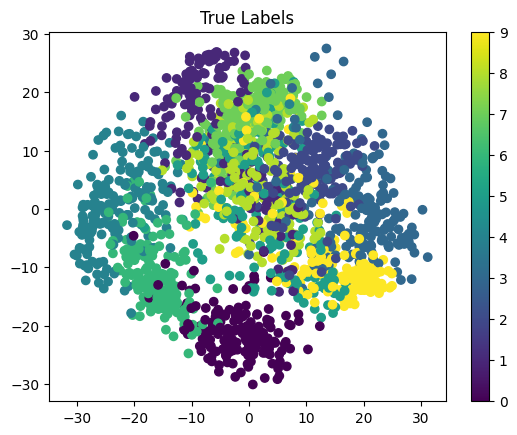

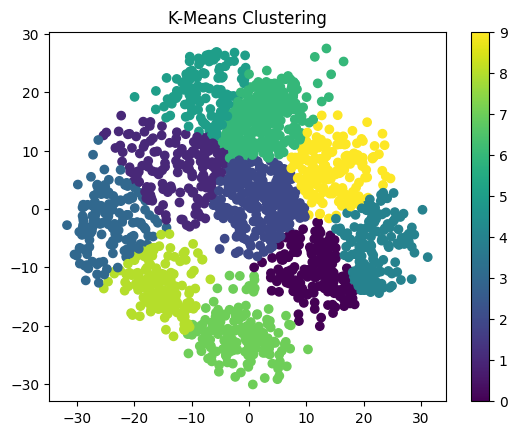

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits
digits = load_digits()
print(digits.keys())
#X[i] is the flattened 64-pixel image, and y[i] is the actual digit that image represents (ie: y[0] = 0 means the first image is a handwritten "0")
X = digits.data
Y = digits.target
print(X.shape, Y.shape) #X = 1797x64
#Part A
#center the data (subtract mean of each feature column from X so that the data is centered at origin, needed because SVD finds direction of maximum variance around the mean)
col_mean = np.mean(X, axis=0)
X_center = X-col_mean
#compute the SVD (decomposes into U=shape, S=1D array of singular values that tells how much variance each corresponding direction captures, Vt=V transpose, each row is a principal component direction, with row 0 of Vt being the direction of highest variance and so on), to reduce to k dimensions, need the first k rows of Vt to project the centered data onto
U, S, Vt = np.linalg.svd(X_center)
#graph decomposition (selects top 2 components of Vt and projects the centered data onto those dimensions)
SVD_2d = X_center @ Vt.T[ : , :2]
plt.figure()
plt.scatter(SVD_2d[: , 0], SVD_2d[: , 1], c=Y)
plt.colorbar()
plt.title("True Labels")
#Part B
#randomly pick k points from the actual data to serve as the starting centroids (1797 data entries, pick 10 random values, then pull those (X, Y) pairs)
random_integer = np.random.choice(1797, size=10, replace=False)
centroids = SVD_2d[random_integer]
#compute the distance between each point and the 10 centroids, figure out which centroid is closest, recompute the centroids
for i in range(100):
  centroid_assignment = []
  for j in range (1797):
    closest_centroid = np.argmin(np.linalg.norm(SVD_2d[j] - centroids, axis=1))
    centroid_assignment.append(closest_centroid)
  for k in range(10):
#each time SVD_2d[np.array(centroid_assignment) == k] is run for a different k, it's a completely fresh, independent filtering operation that produces a brand new array containing only that cluster's points
    points_in_cluster = SVD_2d[np.array(centroid_assignment)==k]
    centroids[k] = np.mean(points_in_cluster, axis=0)
plt.figure()
plt.scatter(SVD_2d[: , 0], SVD_2d[: , 1], c=centroid_assignment)
plt.colorbar()
plt.title("K-Means Clustering")
#Part C
#produce an index that holds the count of how many times index i occurred, take the max to assign value to cluster, then compute accuracy
cluster_accuracy = 0
for i in range(10):
  y_in_cluster = Y[np.array(centroid_assignment)==i]
  y_assign = np.argmax(np.bincount(y_in_cluster))
  accuracy_row = np.sum(y_in_cluster == y_assign)/len(y_in_cluster)
  cluster_accuracy += accuracy_row * ((len(y_in_cluster)/(len(Y))))
print(f"cluster_accuracy = {cluster_accuracy:.4f}")
#Part D
#softmax - have n training points, each with 64 features -> X is nx64, have 10 classes -> weights θ are 64X10, raw score Z=Xθ, Y_pred = exp(Z)/sum(Z), which is used to find gradient of loss function, then update theta
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)
X_train_scaled = X_train/16.0
X_test_scaled = X_test/16.0
def Y_predict(X, theta):
  return np.exp(X @ theta)/np.sum(np.exp(X@theta), axis=1, keepdims=True)
def gradient_theta(X, Y, theta):
  Y_one_hot = np.eye(10)[Y]
  return X.T@(Y_predict(X, theta)-Y_one_hot)
def gradient_descent_theta(theta0, eta, n_steps, X_train, Y_train):
  theta = theta0
  for i in range(n_steps):
    theta = theta - (eta*gradient_theta(X_train, Y_train, theta))
  return theta
theta_final = gradient_descent_theta(np.zeros((64,10)), eta=0.01, n_steps=1000, X_train=X_train_scaled, Y_train=Y_train);
#check softmax accuracy
Y_pred_prob_train = Y_predict(X_train_scaled, theta_final)
Y_pred_value_train = np.argmax(Y_pred_prob_train, axis=1)
Y_pred_accuracy_train = np.sum(Y_pred_value_train == Y_train)/len(Y_train)
print(f"Y_pred_accuracy_train_softmax = {Y_pred_accuracy_train:.4f}")
Y_pred_prob_test = Y_predict(X_test_scaled, theta_final)
Y_pred_value_test = np.argmax(Y_pred_prob_test, axis=1)
Y_pred_accuracy_test = np.sum(Y_pred_value_test == Y_test)/len(Y_test)
print(f"Y_pred_accuracy_test_softmax = {Y_pred_accuracy_test:.4f}")